# Mood music project

In dit project wordt een ML model gemaakt die de emotie van een nummer voorspelt.

## Imports

In [102]:
from dotenv import load_dotenv
import os
import librosa
import librosa.display
import matplotlib.pyplot as plt
import pandas as pd
import time
from sklearn.preprocessing import StandardScaler
import numpy as np
from tqdm import tqdm
import tensorflow as tf

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn


In [9]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("imsparsh/deam-mediaeval-dataset-emotional-analysis-in-music")

print("Path to dataset files:", path)

for item in os.listdir(path):
    print(item)

Path to dataset files: C:\Users\Nima\.cache\kagglehub\datasets\imsparsh\deam-mediaeval-dataset-emotional-analysis-in-music\versions\1
DEAM_Annotations
DEAM_audio
features


In [15]:
for map_naam in ["DEAM_Annotations/annotations", "DEAM_audio/MEMD_audio", "features/features"]:
    pad = os.path.join(path, map_naam)
    print(f"\n {map_naam}:")
    items = os.listdir(pad)
    # Laat de eerste 10 zien zodat het niet te veel wordt
    for item in items[:10]:
        print(f"   {item}")
    if len(items) > 10:
        print(f"   ... en nog {len(items) - 10} bestanden")


 DEAM_Annotations/annotations:
   annotations averaged per song
   annotations per each rater

 DEAM_audio/MEMD_audio:
   10.mp3
   1000.mp3
   1001.mp3
   1002.mp3
   1003.mp3
   1004.mp3
   1005.mp3
   1006.mp3
   1007.mp3
   1008.mp3
   ... en nog 1792 bestanden

 features/features:
   10.csv
   1000.csv
   1001.csv
   1002.csv
   1003.csv
   1004.csv
   1005.csv
   1006.csv
   1007.csv
   1008.csv
   ... en nog 1792 bestanden


### Uitleg data

#### Wat is Valence?
Valence beschrijft hoe blij of droevig een nummer klinkt.

- 0 = Droevig
- 10 = Heel blij
Een trieste pianosolo scoort misschien 0.2. Een vrolijk zomernummer scoort misschien 0.85.


#### Wat is Arousal
Arousal beschrijft hoeveel energie of spanning een nummer heeft.

- 0 = Heel rustig
- 10 = Heel energiek
Een rustig slaapliedje scoort misschien 0.1. Een heavy metal nummer scoort misschien 0.95.

#### Hoe is de data tot stand gekomen?
Dit is het slimme deel van DEAM. Ze hebben echte mensen (tientallen per nummer) gevraagd om te luisteren en een score te geven. De scores zijn dan gemiddeld. Dus het is geen computer die het heeft bedacht, maar echte menselijke emoties.

#### Wat zit er verder in de dataset?
Naast de audio en de valence/arousal scores bevat DEAM ook nog:
- **Per seconde scores** --> niet alleen één score per nummer, maar scores per seconde. Zo kun je zien dat een nummer begint rustig (arousal 0.3) en langzaam opbouwt naar energiek (arousal 0.8). Heel waardevol voor ons model.
- **Gemiddelde scores** --> een simpele gemiddelde valence en arousal voor het hele nummer. Dit is het makkelijkst om mee te beginnen.
- **Metadata** --> informatie zoals de titel, artiest en het jaar van elk nummer.


### Structuur data
- MEMD_audio → 1802 mp3 bestanden, elk nummer heeft een ID (bijv. 10.mp3)
- features → voor elk nummer een CSV met voorberekende audio features
- annotations → de emotie scores van echte mensen

## Labels bekijken

In [ ]:
annotations_pad = os.path.join(path, "DEAM_Annotations/annotations/annotations averaged per song")
print("BESTANDEN IN DEZE MAP:")
for item in os.listdir(annotations_pad):
    print(" ", item)

song_level_pad = os.path.join(annotations_pad, "song_level")

print("SONG LEVEL IN DE MAP")
for item in os.listdir(song_level_pad):
    print(item)


BESTANDEN IN DEZE MAP:
  dynamic (per second annotations)
  song_level
SONG LEVEL IN DE MAP
static_annotations_averaged_songs_1_2000.csv
static_annotations_averaged_songs_2000_2058.csv


In [31]:
# Labels bekijken
pad1 = os.path.join(song_level_pad, "static_annotations_averaged_songs_1_2000.csv")
pad2 = os.path.join(song_level_pad, "static_annotations_averaged_songs_2000_2058.csv")

df1 = pd.read_csv(pad1)
df2 = pd.read_csv(pad2)

df = pd.concat([df1, df2], ignore_index=True)

print("Aantal nummers:", len(df))
print("\nKolommen:")
print(df.columns.tolist())
print("\nEerste 5 rijen:")
display(df.head())
display(df.info())

Aantal nummers: 1802

Kolommen:
['song_id', ' valence_mean', ' valence_std', ' arousal_mean', ' arousal_std', ' valence_ max_mean', ' valence_max_std', ' valence_min_mean', ' valence_min_std', ' arousal_max_mean', ' arousal_max_std', ' arousal_min_mean', ' arousal_min_std']

Eerste 5 rijen:


,song_id,valence_mean,valence_std,arousal_mean,arousal_std,valence_ max_mean,valence_max_std,valence_min_mean,valence_min_std,arousal_max_mean,arousal_max_std,arousal_min_mean,arousal_min_std
0,2,3.1,0.94,3.0,0.63,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3,3.5,1.75,3.3,1.62,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4,5.7,1.42,5.5,1.63,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5,4.4,2.01,5.3,1.85,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,7,5.8,1.47,6.4,1.69,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1802 entries, 0 to 1801
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   song_id             1802 non-null   int64  
 1    valence_mean       1802 non-null   float64
 2    valence_std        1802 non-null   float64
 3    arousal_mean       1802 non-null   float64
 4    arousal_std        1802 non-null   float64
 5    valence_ max_mean  58 non-null     float64
 6    valence_max_std    58 non-null     float64
 7    valence_min_mean   58 non-null     float64
 8    valence_min_std    58 non-null     float64
 9    arousal_max_mean   58 non-null     float64
 10   arousal_max_std    58 non-null     float64
 11   arousal_min_mean   58 non-null     float64
 12   arousal_min_std    58 non-null     float64
dtypes: float64(12), int64(1)
memory usage: 183.1 KB


None

## Data opschonen

In [38]:
# Alleen de kolommen die we nodig hebben
#df = df[["song_id", " valence_mean", " arousal_mean"]].copy()

# Kolomnamen opschonen 
df.columns = ["song_id", "valence", "arousal"]

# Schaal van 1-9 omzetten naar 0-1
df["valence"] = (df["valence"] - 1) / 8
df["arousal"] = (df["arousal"] - 1) / 8

print("Opgeschoonde data:")
print(df.head())
print("\nGemiddelde valence:", df["valence"].mean().round(3))
print("Gemiddelde arousal:", df["arousal"].mean().round(3))

Opgeschoonde data:
   song_id  valence  arousal
0        2   0.2625   0.2500
1        3   0.3125   0.2875
2        4   0.5875   0.5625
3        5   0.4250   0.5375
4        7   0.6000   0.6750

Gemiddelde valence: 0.488
Gemiddelde arousal: 0.477


### Checken of audio en labels overeenkomen

In [60]:
audio_pad= os.path.join(path, "DEAM_audio/MEMD_audio")

audio_ids = [int(f.replace(".mp3", "")) for f in os.listdir(audio_pad) if f.endswith(".mp3")]
label_ids = df["song_id"].tolist()
beide = [id for id in label_ids if id in audio_ids]


print(f"Nummers met label: {len(label_ids)}")
print(f"Nummers met audio: {len(audio_ids)}")
print(f"Nummers met allebei: {len(beide)}")

# Alleen nummers bewaren die audio EN label hebben
df = df[df["song_id"].isin(beide)].reset_index(drop=True)
print(f"\nDataset  met {len(df)} nummers")



Nummers met label: 1802
Nummers met audio: 1802
Nummers met allebei: 1802

Dataset  met 1802 nummers


### eerste nummer checken

In [64]:
df

,song_id,valence,arousal
0,2,0.26250,0.25000
1,3,0.31250,0.28750
2,4,0.58750,0.56250
3,5,0.42500,0.53750
4,7,0.60000,0.67500
...,...,...,...
1797,2054,0.55000,0.32500
1798,2055,0.50000,0.52500
1799,2056,0.50000,0.45000
1800,2057,0.27125,0.72875


In [72]:
eerste_id = df["song_id"][0]
audio_bestand = os.path.join(audio_pad, f"{eerste_id}.mp3")

y, sr = librosa.load(audio_bestand, duration=30)

print(f"Nummer ID: {eerste_id}")
print(f"Valence: {df['valence'][0]:.2f}  →  {'blij ' if df['valence'][0] > 0.5 else 'droevig '}")
print(f"Arousal: {df['arousal'][0]:.2f}  →  {'energiek ' if df['arousal'][0] > 0.5 else 'rustig '}")


Nummer ID: 2
Valence: 0.26  →  droevig 
Arousal: 0.25  →  rustig 


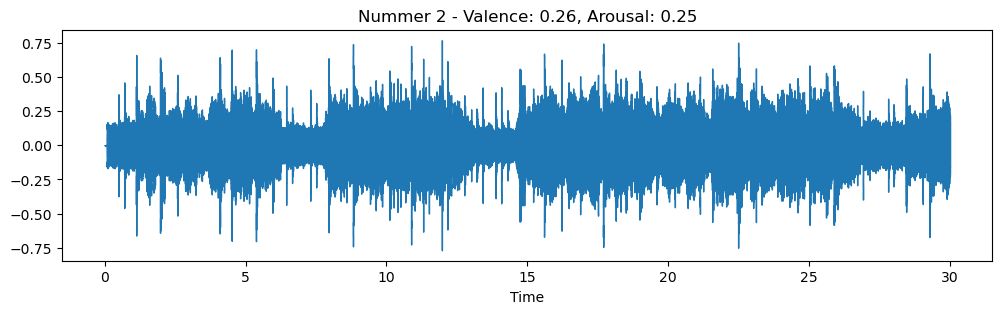

In [78]:
plt.figure(figsize=(12,3))
librosa.display.waveshow(y, sr=sr)
plt.title(f"Nummer {eerste_id} - Valence: {df['valence'][0]:.2f}, Arousal: {df['arousal'][0]:.2f}")
plt.show()

### MEL Spectogram maken

### Wat doet de code?

`librosa.feature.melspectrogram(...)`
- Dit zet het geluid om naar een soort foto van het geluid. Het splitst het nummer op in stukjes van milliseconden en kijkt per stukje welke tonen er klinken en hoe hard.

`librosa.power_to_db(...)`
- De getallen die we krijgen zijn heel groot en klein door elkaar. Dit zet ze om naar decibel (dB) zodat het makkelijker te zien en te vergelijken is. Net zoals je volumeknop ook in dB werkt.

`n_mels=128`
- We verdelen het geluid in 128 frequentieniveaus. Meer niveaus betekent meer detail.

### Wat betekent de mel spectogram
De afbeelding heeft drie assen:
1. Horizontaal (Time) is de tijd in seconden. Het nummer is 30 seconden lang dus je ziet 0 tot 30.
2. Verticaal (Hz) zijn de frequenties. Onderaan zitten de lage tonen zoals een bas of kick drum. Bovenaan zitten de hoge tonen zoals een hi-hat of viool.
3. De kleur geeft aan hoe hard een toon klinkt. Oranje/geel betekent luid. Paars/donker betekent zacht of afwezig.

### Wat vertelt dit over nummer 2?
Omdat dit nummer droevig en rustig is (valence 0.26, arousal 0.25) zie je:
Onderin veel oranje, dus er zijn lage tonen aanwezig. Bovenin veel paars, dus weinig hoge energie tonen. Geen heel felle gele pieken, wat betekent dat er geen harde slagen of veel energie in zit. Precies wat je verwacht van een rustig en droevig nummer.

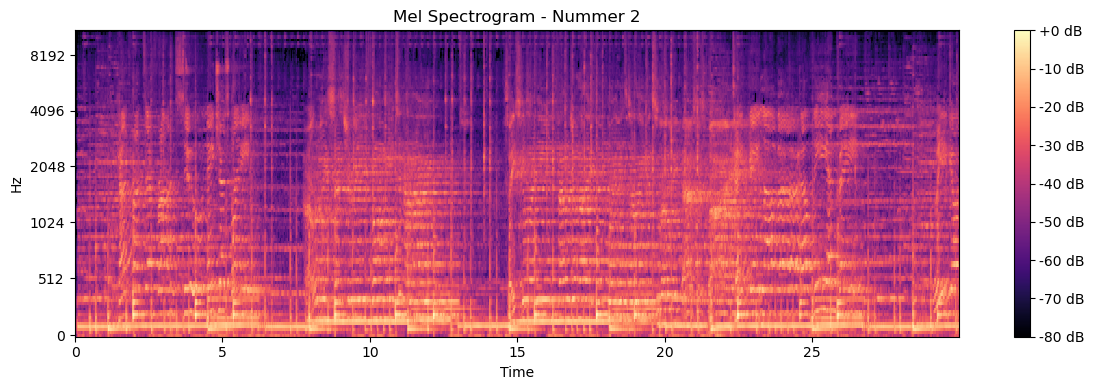

Vorm van het spectrogram: (128, 1292)


In [80]:
mel_spec  = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

plt.figure(figsize=(12, 4))
librosa.display.specshow(mel_spec_db, sr=sr, x_axis="time", y_axis="mel")
plt.colorbar(format="%+2.0f dB")
plt.title(f"Mel Spectrogram - Nummer {eerste_id}")
plt.tight_layout()
plt.show()

print("Vorm van het spectrogram:", mel_spec_db.shape)



### Alle nummers naar spectogrammen

Elk nummer wordt een "foto" van 128x128 pixels. We kiezen 128x128 omdat dat klein genoeg is om snel te trainen maar groot genoeg om patronen in te herkennen. De 1292 tijdstappen schalen we terug naar 128.

In [82]:
DOEL_VORM = (128, 128)  # elke spectrogram wordt 128x128
spectrogrammen = []
labels = []
gevonden_ids = []

In [84]:
print(df["song_id"].dtype)
print(df["song_id"].head())

int64
0    2
1    3
2    4
3    5
4    7
Name: song_id, dtype: int64


In [85]:
for _, rij in tqdm(df.iterrows(), total=len(df)):
    song_id = rij["song_id"]
    bestand = os.path.join(audio_pad, f"{int(song_id)}.mp3")
    
    try:
        # Laad 30 seconden audio
        y, sr = librosa.load(bestand, duration=30, sr=22050)
        
        # Maak mel spectrogram
        mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        
        # Schaal naar 128x128
        mel_resized = np.resize(mel_db, DOEL_VORM)
        
        # Normaliseer tussen 0 en 1
        mel_norm = (mel_resized - mel_resized.min()) / (mel_resized.max() - mel_resized.min())
        
        spectrogrammen.append(mel_norm)
        labels.append([rij["valence"], rij["arousal"]])
        gevonden_ids.append(song_id)
        
    except Exception as e:
        print(f"Fout bij nummer {song_id}: {e}")


# Omzetten naar numpy arrays
X = np.array(spectrogrammen)  # vorm: (1802, 128, 128)
y_labels = np.array(labels)   # vorm: (1802, 2)

print(f"\nKlaar!")
print(f"X vorm: {X.shape}")
print(f"y vorm: {y_labels.shape}")

100%|██████████| 1802/1802 [03:16<00:00,  9.19it/s]


Klaar!
X vorm: (1802, 128, 128)
y vorm: (1802, 2)


In [86]:
# Oplsaan
np.save("X_spectrogrammen.npy", X)
np.save("y_labels.npy", y_labels)

print("Opgeslagen!")
print("X_spectrogrammen.npy")
print("y_labels.npy")

Opgeslagen!
X_spectrogrammen.npy
y_labels.npy


In [98]:
X = np.load("X_spectrogrammen.npy")
y_labels = np.load("y_labels.npy")

print("Ingeladen!")
print(f"X vorm: {X.shape}")
print(f"y vorm: {y_labels.shape}")

Ingeladen!
X vorm: (1802, 128, 128)
y vorm: (1802, 2)


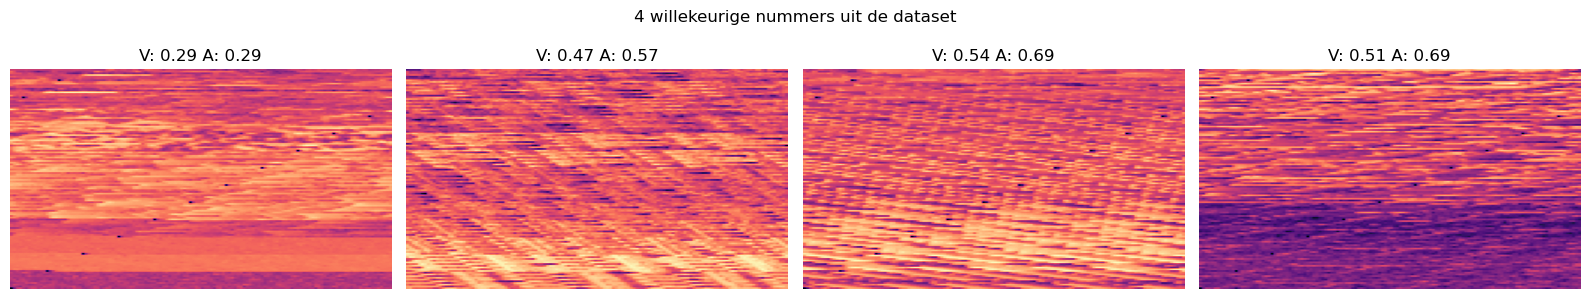

In [99]:

# Laat 4 willekeurige nummers zien met hun labels
fig, axes = plt.subplots(1, 4, figsize=(16, 3))

for i, ax in enumerate(axes):
    idx = np.random.randint(0, len(X))
    ax.imshow(X[idx], aspect="auto", origin="lower", cmap="magma")
    ax.set_title(f"V: {y_labels[idx][0]:.2f} A: {y_labels[idx][1]:.2f}")
    ax.axis("off")

plt.suptitle("4 willekeurige nummers uit de dataset")
plt.tight_layout()
plt.show()

### Bouwen van modellen

1. Model 1: Simpele CNN          → onze baseline, simpel en snel
2. Model 2: Diepere CNN          → meer lagen, meer detail
3. Model 3: CNN + Attention      → het model focust op belangrijke delen
4. Model 4: Pretrained ResNet18  → transfer learning, geleerd op miljoenen afbeeldingen

- MSE (Mean Squared Error) — hoe ver zit de voorspelling van de echte waarde
- MAE (Mean Absolute Error) — gemiddelde fout in begrijpelijke getallen
- Trainingstijd — hoe lang duurt het

Voor MAE geldt: 
- MAE 0.20+   →  Slecht,  het model gokt bijna
- MAE 0.15    →  Matig,   richting klopt maar onnauwkeurig
- MAE 0.10    →  Goed  ✓  waar The Rookie nu zit
- MAE 0.07    →  Zeer goed
- MAE 0.05    →  Uitstekend

In [100]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_labels, test_size=0.2, random_state=42
)

print(f"Trainset:  {X_train.shape[0]} nummers")
print(f"Testset:   {X_test.shape[0]} nummers")

Trainset:  1441 nummers
Testset:   361 nummers


In [107]:
import tensorflow as tf
from sklearn.model_selection import train_test_split

# 80% trainen, 20% testen
X_train, X_test, y_train, y_test = train_test_split(
    X, y_labels, test_size=0.2, random_state=42
)

# Voeg kleurkanaal toe: (N, 128, 128, 1)
# TensorFlow verwacht de vorm (batch, hoogte, breedte, kanalen)
X_train = X_train[..., np.newaxis]
X_test  = X_test[..., np.newaxis]

print(f"Trainset:  {X_train.shape}")
print(f"Testset:   {X_test.shape}")


device = torch.device("cuda")
print(f"Gebruik: {device}")


Trainset:  (1441, 128, 128, 1)
Testset:   (361, 128, 128, 1)
Gebruik: cuda


In [115]:
class MuziekDataset(Dataset):
    def __init__(self, X, y):
        # Zorg dat X altijd 3D is (N, 128, 128) voor we unsqueeze doen
        if X.ndim == 4:
            X = X[..., 0]  # verwijder extra kanaal
        
        # (N, 128, 128) → (N, 1, 128, 128)
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(1)
        self.y = torch.tensor(y, dtype=torch.float32)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = MuziekDataset(X_train, y_train)
test_dataset  = MuziekDataset(X_test,  y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

print(f"Trainset batches:  {len(train_loader)}")
print(f"Testset batches:   {len(test_loader)}")

X_check, y_check = next(iter(train_loader))
print(f"Batch vorm: {X_check.shape}")  # moet zijn: [32, 1, 128, 128]

Trainset batches:  46
Testset batches:   12
Batch vorm: torch.Size([32, 1, 128, 128])


In [112]:
def train_model(model, train_loader, test_loader, epochs=30, lr=0.001):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    
    geschiedenis = {"train_loss": [], "test_loss": [], "test_mae": []}
    
    for epoch in range(epochs):
        # Trainen
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            optimizer.zero_grad()
            voorspelling = model(X_batch)
            loss = loss_fn(voorspelling, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        # Evalueren
        model.eval()
        test_loss = 0
        test_mae = 0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)
                voorspelling = model(X_batch)
                test_loss += loss_fn(voorspelling, y_batch).item()
                test_mae  += torch.mean(torch.abs(voorspelling - y_batch)).item()
        
        train_loss /= len(train_loader)
        test_loss  /= len(test_loader)
        test_mae   /= len(test_loader)
        
        geschiedenis["train_loss"].append(train_loss)
        geschiedenis["test_loss"].append(test_loss)
        geschiedenis["test_mae"].append(test_mae)
        
        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1:02d}/{epochs} | Train loss: {train_loss:.4f} | Test loss: {test_loss:.4f} | MAE: {test_mae:.4f}")
    
    return geschiedenis

def plot_geschiedenis(geschiedenis, naam):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    axes[0].plot(geschiedenis["train_loss"], label="Train")
    axes[0].plot(geschiedenis["test_loss"],  label="Test")
    axes[0].set_title(f"{naam} - Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()
    
    axes[1].plot(geschiedenis["test_mae"], label="MAE", color="orange")
    axes[1].set_title(f"{naam} - MAE")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
    
    print(f"Beste MAE: {min(geschiedenis['test_mae']):.4f}")

print("Functies klaar!")

Functies klaar!


### Model 1- The Rookie

1. Conv2d lagen kijken naar kleine stukjes van het spectrogram en zoeken patronen, zoals een rand, een lijn, of een herhaling. Elke laag zoekt complexere patronen dan de vorige.
2. MaxPool2d maakt de afbeelding twee keer zo klein. Zo focust het model op de grote patronen en niet op elk pixel apart.
3. Flatten + Linear zet alles om naar een rij getallen en berekent uiteindelijk de valence en arousal score.
4. Dropout zet tijdens het trainen willekeurig 30% van de verbindingen uit. Dit voorkomt dat het model de traindata uit zijn hoofd leert.

Beste MAE: 0.0985 betekent dat het model gemiddeld maar 0.10 punt naast de echte score zit op een schaal van 0 tot 1. Dat is indrukwekkend voor een eerste model

In [116]:
class TheRookie(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.conv_lagen = nn.Sequential(
            # Laag 1
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),          # 128x128 → 64x64

            # Laag 2
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),          # 64x64 → 32x32

            # Laag 3
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),          # 32x32 → 16x16
        )
        
        self.fc_lagen = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 16 * 16, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 2)         # output: valence + arousal
        )
    
    def forward(self, x):
        x = self.conv_lagen(x)
        x = self.fc_lagen(x)
        return x

rookie = TheRookie()
print(rookie)
print(f"\nAantal parameters: {sum(p.numel() for p in rookie.parameters()):,}")

TheRookie(
  (conv_lagen): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_lagen): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=16384, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=2, bias=True)
  )
)

Aantal parameters: 4,218,370


Trainen van The Rookie...
Epoch 05/30 | Train loss: 0.0266 | Test loss: 0.0213 | MAE: 0.1182
Epoch 10/30 | Train loss: 0.0204 | Test loss: 0.0169 | MAE: 0.1053
Epoch 15/30 | Train loss: 0.0197 | Test loss: 0.0169 | MAE: 0.1046
Epoch 20/30 | Train loss: 0.0183 | Test loss: 0.0159 | MAE: 0.1013
Epoch 25/30 | Train loss: 0.0165 | Test loss: 0.0161 | MAE: 0.1014
Epoch 30/30 | Train loss: 0.0134 | Test loss: 0.0171 | MAE: 0.1042


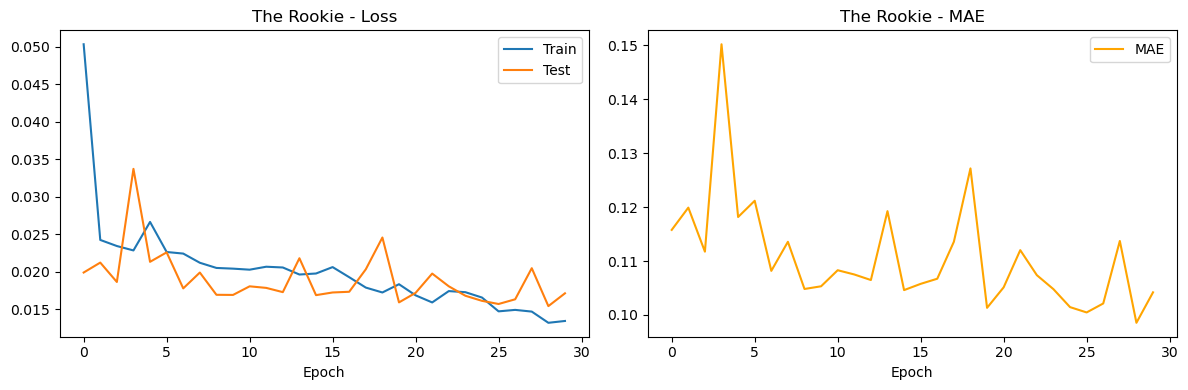

Beste MAE: 0.0985


In [117]:
print("Trainen van The Rookie...")
rookie = TheRookie()
geschiedenis_rookie = train_model(rookie, train_loader, test_loader, epochs=30)
plot_geschiedenis(geschiedenis_rookie, "The Rookie")

In [118]:
torch.save(rookie.state_dict(), "the_rookie.pth")
print("The Rookie opgeslagen als the_rookie.pth!")

# Inladen 
rookie_geladen = TheRookie()
rookie_geladen.load_state_dict(torch.load("the_rookie.pth"))
rookie_geladen.eval()
print("The Rookie ingeladen!")

The Rookie opgeslagen als the_rookie.pth!
The Rookie ingeladen!


## The Veteran
#### Wat is nieuw ten opzichte van The Rookie?
1. Dubbele conv lagen per blok — elk blok heeft nu twee conv lagen achter elkaar. Dit geeft het model meer tijd om patronen te leren voordat het de afbeelding verkleint.
2. BatchNorm2d — normaliseert de waarden na elke conv laag. Dit zorgt dat het model stabieler en sneller leert. Zie het als het kalibreren van een instrument.
3. Dropout2d — zet willekeurig hele kanalen uit tijdens het trainen, dit voorkomt dat het model te afhankelijk wordt van specifieke patronen.
4. 4 blokken in plaats van 3 — meer lagen betekent dat het model complexere patronen kan herkennen.

In [119]:
class TheVeteran(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.conv_lagen = nn.Sequential(
            # Blok 1
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),          # 128x128 → 64x64
            nn.Dropout2d(0.2),

            # Blok 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),          # 64x64 → 32x32
            nn.Dropout2d(0.2),

            # Blok 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),          # 32x32 → 16x16
            nn.Dropout2d(0.2),

            # Blok 4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),          # 16x16 → 8x8
        )
        
        self.fc_lagen = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 8 * 8, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 2)
        )
    
    def forward(self, x):
        x = self.conv_lagen(x)
        x = self.fc_lagen(x)
        return x

veteran = TheVeteran()
print(veteran)
print(f"\nAantal parameters: {sum(p.numel() for p in veteran.parameters()):,}")

TheVeteran(
  (conv_lagen): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.2, inplace=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (15): Dropout2d(p=0.2, 

Trainen van The Veteran...
Epoch 05/30 | Train loss: 0.0674 | Test loss: 0.0428 | MAE: 0.1675
Epoch 10/30 | Train loss: 0.0531 | Test loss: 0.0449 | MAE: 0.1766
Epoch 15/30 | Train loss: 0.0441 | Test loss: 0.0236 | MAE: 0.1246
Epoch 20/30 | Train loss: 0.0454 | Test loss: 0.0253 | MAE: 0.1285
Epoch 25/30 | Train loss: 0.0346 | Test loss: 0.0210 | MAE: 0.1179
Epoch 30/30 | Train loss: 0.0336 | Test loss: 0.0185 | MAE: 0.1106


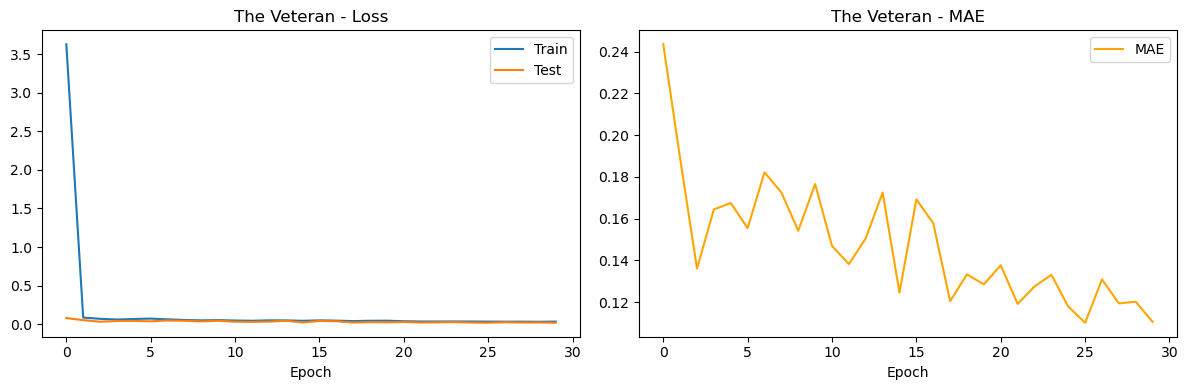

Beste MAE: 0.1102
The Veteran verder trainen...
Epoch 05/20 | Train loss: 0.0258 | Test loss: 0.0208 | MAE: 0.1170
Epoch 10/20 | Train loss: 0.0214 | Test loss: 0.0202 | MAE: 0.1155
Epoch 15/20 | Train loss: 0.0191 | Test loss: 0.0291 | MAE: 0.1383
Epoch 20/20 | Train loss: 0.0193 | Test loss: 0.0202 | MAE: 0.1159


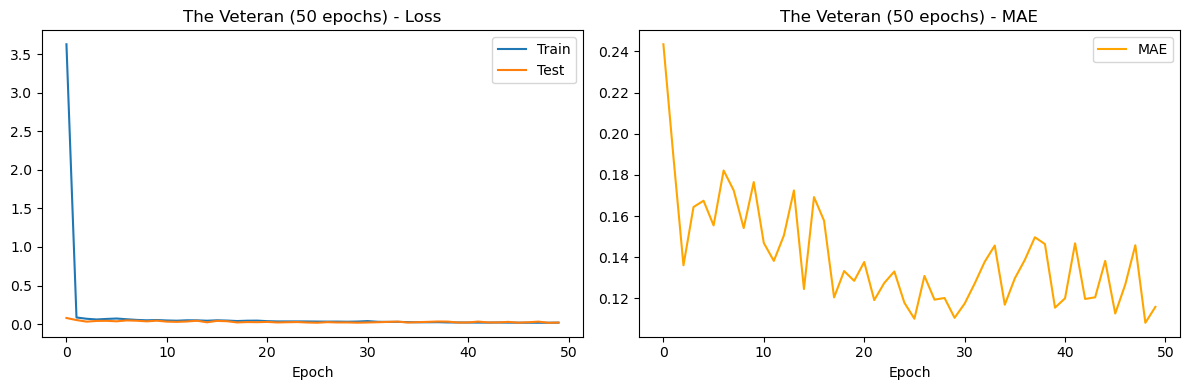

Beste MAE: 0.1082


In [124]:
print("Trainen van The Veteran...")
veteran = TheVeteran()
geschiedenis_veteran = train_model(veteran, train_loader, test_loader, epochs=30)
plot_geschiedenis(geschiedenis_veteran, "The Veteran")

print("The Veteran verder trainen...")
geschiedenis_veteran2 = train_model(veteran, train_loader, test_loader, epochs=20)

# Combineer de geschiedenis
for key in geschiedenis_veteran:
    geschiedenis_veteran[key].extend(geschiedenis_veteran2[key])

plot_geschiedenis(geschiedenis_veteran, "The Veteran (50 epochs)")

In [125]:
torch.save(veteran.state_dict(), "the_veteran.pth")
print("The veteran opgeslagen als the_veteran.pth!")

# Inladen 
veteran_geladen = TheVeteran()
veteran_geladen.load_state_dict(torch.load("the_veteran.pth"))
veteran_geladen.eval()
print("The veteran ingeladen!")

The veteran opgeslagen als the_veteran.pth!
The veteran ingeladen!
